1. Selecione uma serie temporal de sua preferência com dados faltantes ou selecionar uma completa. Elimine algumas observações e estime as utilizando diferentes técnicas. Em seguida, compare os dados estimados com aqueles eliminados. (Seleciona o de maior acurácia)

In [1]:
# usando python 3.11.9
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def plotar(serie, titulo, y='USD'):
    plt.figure(figsize=(10, 4))
    plt.plot(serie)
    plt.title(titulo)
    plt.xlabel('Tempo')
    plt.ylabel(y)
    plt.show()

In [2]:
df = pd.read_csv('exchange_rates.csv')
# Conversão da coluna de data e definição como índice
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
ts = df[df['currency'] == 'USD']
ts = ts.drop(['Unnamed: 0', 'Country/Currency', 'currency'], axis=1)
ts

C:\Users\Beatriz\AppData\Local\Temp\ipykernel_26392\2478470535.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


,value
date,
2021-12-17,1.132548
2021-12-18,1.123810
2021-12-19,1.123810
2021-12-20,1.124405
2021-12-21,1.128382
...,...
2025-10-23,1.160827
2025-10-24,1.161713
2025-10-25,1.162650


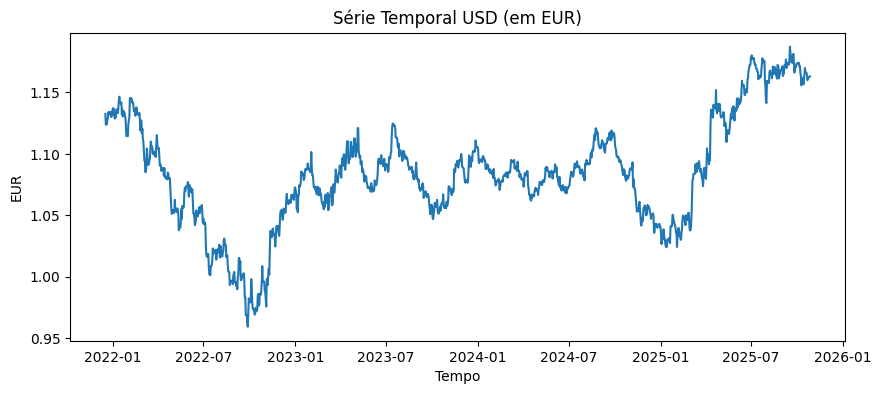

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(ts['value'])
plt.title('Série Temporal USD (em EUR)')
plt.xlabel('Tempo')
plt.ylabel('EUR')
plt.show()

In [4]:
ts_missing_block = ts.copy()

data_inicio_remocao = '2022-03-01'
data_fim_remocao = '2022-05-31'

# Removendo (substituindo por NaN) o bloco de dados
ts_missing_block.loc[data_inicio_remocao:data_fim_remocao] = np.nan

data_inicio_remocao = '2023-01-01'
data_fim_remocao = '2023-03-31'

# Removendo (substituindo por NaN) o bloco de dados
ts_missing_block.loc[data_inicio_remocao:data_fim_remocao] = np.nan

data_inicio_remocao = '2024-05-01'
data_fim_remocao = '2024-06-30'

# Removendo (substituindo por NaN) o bloco de dados
ts_missing_block.loc[data_inicio_remocao:data_fim_remocao] = np.nan

data_inicio_remocao = '2024-12-01'
data_fim_remocao = '2025-02-28'

# Removendo (substituindo por NaN) o bloco de dados
ts_missing_block.loc[data_inicio_remocao:data_fim_remocao] = np.nan

print(f"Número de observações removidas em bloco: {ts_missing_block.isna().sum()}")

Número de observações removidas em bloco: value    332
dtype: int64


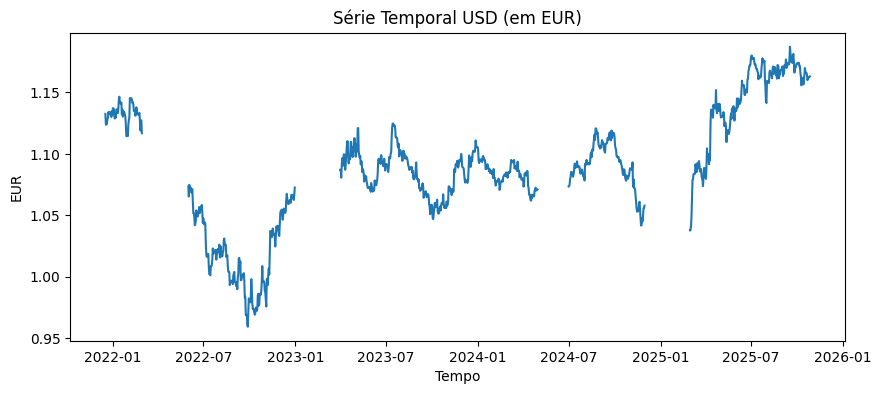

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(ts_missing_block['value'])
plt.title('Série Temporal USD (em EUR)')
plt.xlabel('Tempo')
plt.ylabel('EUR')
plt.show()

In [6]:
# Identifica os índices (datas) onde há NaN na série modificada (ts_missing_multi)
indices_removidos = ts_missing_block[ts_missing_block.isna()].index

# Cria a série com os dados verdadeiros (Ground Truth) para comparação
dados_eliminados_verdadeiros = ts.loc[indices_removidos]

# Remove os NaNs da série modificada (opcional, dependendo de como você vai imputar)
ts_para_imputacao = ts_missing_block.dropna() 

print("\nExemplo dos dados verdadeiros eliminados:")
print(dados_eliminados_verdadeiros.head())

# Agora você tem:
# ts_missing_multi: A série completa com os buracos (NaN) para você preencher.
# dados_eliminados_verdadeiros: Os valores que você deve acertar.


Exemplo dos dados verdadeiros eliminados:
               value
date                
2021-12-17  1.132548
2021-12-18  1.123810
2021-12-19  1.123810
2021-12-20  1.124405
2021-12-21  1.128382


Estimando com diferentes técnicas:

In [ ]:
ts_com_nan = ts_missing_block

In [33]:
# 1. TÉCNICA 1: Imputação Simples (Baseline)
# Usando a média de toda a série
ts_media = ts_com_nan.fillna(ts_com_nan.mean())

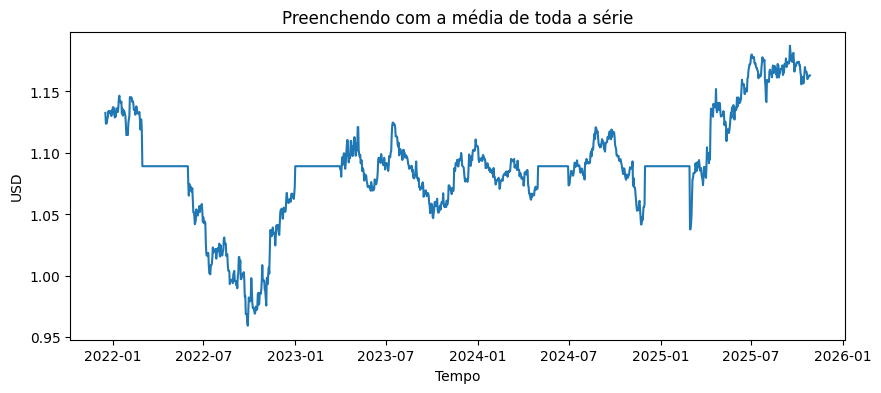

In [34]:
plotar(ts_media, 'Preenchendo com a média de toda a série')

In [35]:
# Usando a Última Observação Válida (LOCF - Last Observation Carried Forward)
ts_locf = ts_com_nan.fillna(method='ffill') 

C:\Users\Beatriz\AppData\Local\Temp\ipykernel_26392\4067356391.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts_locf = ts_com_nan.fillna(method='ffill')


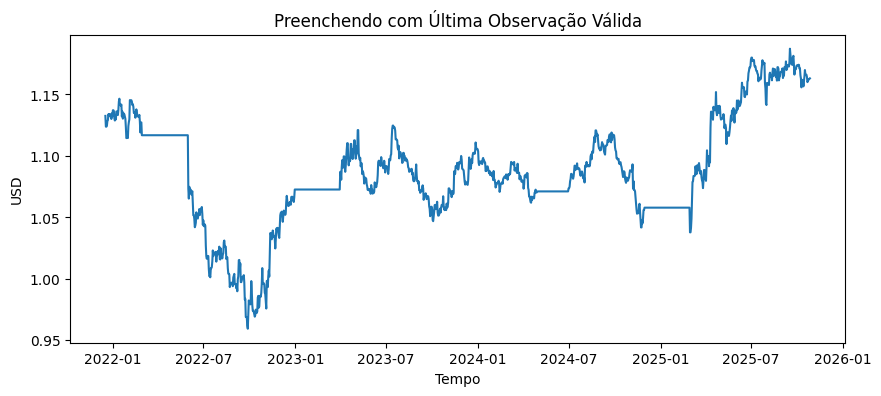

In [14]:
plotar(ts_locf, 'Preenchendo com Última Observação Válida')

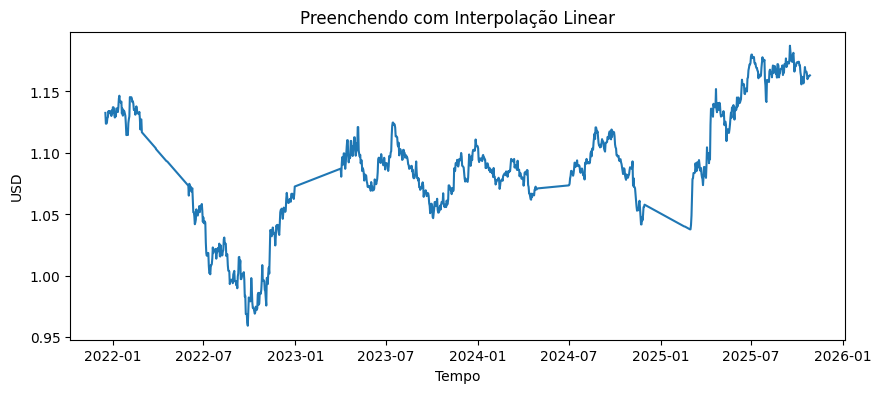

In [36]:
# 2. TÉCNICA 2: Imputação Baseada em Séries Temporais (Pandas Interpolate)
# Interpolação Linear (usa os vizinhos para traçar uma linha reta)
ts_linear = ts_com_nan.interpolate(method='linear')

plotar(ts_linear, 'Preenchendo com Interpolação Linear')

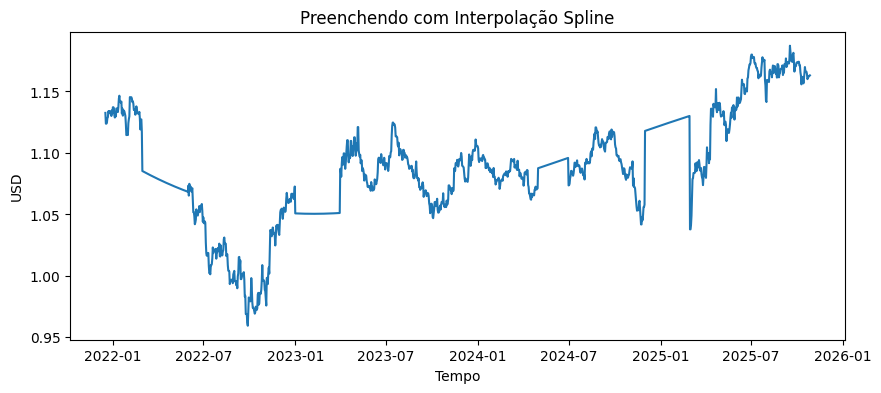

In [37]:
# Interpolação Spline (usa funções polinomiais de grau 3 para suavizar)
ts_spline = ts_com_nan.interpolate(method='spline', order=3)

plotar(ts_spline, 'Preenchendo com Interpolação Spline')

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [31]:
# Valores originais que foram removidos
ground_truth = ts.loc[indices_removidos]

In [ ]:
# ====================================================================
# C. COMPARAÇÃO E SELEÇÃO DA MELHOR ESTIMAÇÃO
# ====================================================================

# Lista de todas as séries imputadas para iteração
series_imputadas = {
    "Média (Baseline)": ts_media,
    "LOCF (Last Observation)": ts_locf,
    "Interpolação Linear": ts_linear,
    "Interpolação Spline (Ordem 3)": ts_spline,
}

resultados = {}

print("--- Resultados da Comparação (Acurácia) ---")

for nome, ts_imputada in series_imputadas.items():
    # 1. Extrair Apenas os Valores Imputados (os que preenchem os NaNs originais)
    
    # Valores estimados (imputados) nos índices faltantes
    valores_estimados = ts_imputada.loc[indices_removidos]
    
    # 2. Calcular as Métricas de Erro (comparando estimado vs. verdadeiro)
    
    # MSE: Erro Quadrático Médio
    mse = mean_squared_error(ground_truth, valores_estimados)
    
    # RMSE: Raiz do Erro Quadrático Médio
    rmse = np.sqrt(mse)
    
    # MAE: Erro Médio Absoluto
    mae = mean_absolute_error(ground_truth, valores_estimados)
    
    # Armazenar resultados
    resultados[nome] = {'RMSE': rmse, 'MAE': mae}

    print(f"\n[{nome}]")
    print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.6f}")
    print(f"MAE (Erro Médio Absoluto): {mae:.6f}")

# ====================================================================
# SELEÇÃO DA MELHOR TÉCNICA
# ====================================================================

# Cria um DataFrame para facilitar a visualização e comparação final
df_resultados = pd.DataFrame(resultados).T 

# Seleciona a melhor técnica baseada no RMSE (o menor valor é o melhor)
melhor_tecnica_rmse = df_resultados['RMSE'].idxmin()

print("\n" + "="*50)
print("COMPARAÇÃO FINAL DAS MÉTRICAS DE ERRO:")
print(df_resultados.sort_values(by='RMSE'))
print("="*50)
print(f"🥇 A técnica de maior acurácia (menor RMSE) é: {melhor_tecnica_rmse}")

--- Resultados da Comparação (Acurácia) ---

[Média (Baseline)]
RMSE (Raiz do Erro Quadrático Médio): 0.014562
MAE (Erro Médio Absoluto): 0.005679

[LOCF (Last Observation)]
RMSE (Raiz do Erro Quadrático Médio): 0.012259
MAE (Erro Médio Absoluto): 0.004363

[Interpolação Linear]
RMSE (Raiz do Erro Quadrático Médio): 0.006998
MAE (Erro Médio Absoluto): 0.002682

[Interpolação Spline (Ordem 3)]
RMSE (Raiz do Erro Quadrático Médio): 0.022537
MAE (Erro Médio Absoluto): 0.008259

COMPARAÇÃO FINAL DAS MÉTRICAS DE ERRO:
                                   RMSE       MAE
Interpolação Linear            0.006998  0.002682
LOCF (Last Observation)        0.012259  0.004363
Média (Baseline)               0.014562  0.005679
Interpolação Spline (Ordem 3)  0.022537  0.008259
🥇 A técnica de maior acurácia (menor RMSE) é: Interpolação Linear


2. Admita que existem outliers nos dados. Como resolver?

3. Utilize técnicas de simulação de montecarlo para gerar séries temporais do tipo AR1 e AR2.